# 11 — Pump stop sweep: where is the compromise?

nb10 showed the pump fade has a real edge with **no stop** (win 58%, median +1.12%)
but a brutal unbounded short tail (worst trade −96%). The question: a **wide
catastrophe stop** should chop off that tail while leaving the median edge intact.
Sweep the stop from tight to none and find the sweet spot.

Stops: **7, 10, 15, 20, 25, 30, 40, 50, 70, 100%, and no-stop**. For every pump
event we precomputed the pnl + exit time under each stop in one pass
(`_build_pump_stopsweep.py`, realistic intrabar trigger + gap fill + slip). For
each stop we retrain the WF classifier on *that stop's* pnl, keep pred>0, and run
the engine — pump-only and combined (+ realistic dump).

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import show
import numpy as np, pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor

X = pd.read_parquet("_out/pump_stopsweep.parquet")
REAL = pd.read_parquet("_out/faithful_liq_realistic.parquet")
def naive(s): return pd.to_datetime(s).dt.tz_localize(None) if pd.to_datetime(s).dt.tz is not None else pd.to_datetime(s)
DUMP = REAL[REAL.stream=="dump"].copy()
DUMP["entry"]=naive(DUMP["entry"]); DUMP["exit_ts"]=naive(DUMP["exit_ts"])
X["entry"]=naive(X["entry"])
for i in range(11): X[f"exit{i}"]=naive(X[f"exit{i}"])
STOPS=[0.07,0.10,0.15,0.20,0.25,0.30,0.40,0.50,0.70,1.00,np.inf]
PF=["r1","r3","r5","r15","r30","accel5","surge15","surge1","rvol60","rng5","dist_hi240","dist_lo60"]
def lab(S): return f"{S:.0%}" if np.isfinite(S) else "no-stop"
print(f"{len(X)} raw pump events; {len(DUMP)} dump events")

12034 raw pump events; 3760 dump events


In [2]:
def wf_filter(df, label):
    pred=np.full(len(df),np.nan)
    cuts=[int(len(df)*q) for q in (0.40,0.55,0.70,0.85,1.0)]; prev=cuts[0]
    for cut in cuts[1:]:
        tr=df.iloc[:prev]
        m=HistGradientBoostingRegressor(max_depth=3,learning_rate=0.05,max_iter=300,
            l2_regularization=1.0,min_samples_leaf=50,random_state=0).fit(tr[PF],tr[label])
        pred[prev:cut]=m.predict(df.iloc[prev:cut][PF]); prev=cut
    keep=(pred>0)|np.isnan(pred)
    return df[keep]

def run_engine(df, f=0.02, n_slots=50, reserve=0.10, start=1000.0):
    df=df.sort_values("entry").reset_index(drop=True)
    eq=start; cash=eq; openp=[]; ents=df.entry.values; exs=df.exit_ts.values; pnls=df.pnl.values; rec=[]
    for i in range(len(df)):
        now=ents[i]; still=[]
        for (xt,no,pl) in openp:
            if xt<=now: cash+=no*(1+pl); eq+=no*pl
            else: still.append((xt,no,pl))
        openp=still; rec.append((now,eq))
        if len(openp)>=n_slots: continue
        want=f*eq; avail=eq*(1-reserve)-sum(no for _,no,_ in openp); no=min(want,max(0,avail),cash)
        if no<=0: continue
        cash-=no; openp.append((exs[i],no,pnls[i]))
    for (_,no,pl) in openp: eq+=no*pl
    s=pd.Series([e for _,e in rec], index=pd.to_datetime([t for t,_ in rec]))
    daily=s.resample("D").last().ffill(); r=daily.pct_change().dropna()
    sh=r.mean()/r.std()*np.sqrt(365) if r.std()>0 else np.nan
    dd=(daily/daily.cummax()-1).min(); yrs=(daily.index[-1]-daily.index[0]).days/365.25
    return dict(final=eq, cagr=(eq/start)**(1/yrs)-1, sharpe=sh, maxdd=dd)

rows=[]
for i,S in enumerate(STOPS):
    base=X[["sym","entry","liq"]+PF].copy()
    base["pnl"]=X[f"pnl{i}"].values; base["exit_ts"]=X[f"exit{i}"].values
    kept=wf_filter(base, "pnl")
    pk=kept.pnl.values
    pu=run_engine(kept[["entry","exit_ts","pnl","liq"]], 0.02)
    comb=pd.concat([kept[["entry","exit_ts","pnl"]].assign(liq=kept.liq),
                    DUMP[["entry","exit_ts","pnl"]].assign(liq=DUMP.liq if "liq" in DUMP else 1e9)]).reset_index(drop=True)
    ce=run_engine(comb, 0.02)
    rows.append(dict(stop=lab(S), keptN=len(kept), mean=pk.mean()*100, median=np.median(pk)*100,
                     win=(pk>0).mean()*100, worst=pk.min()*100,
                     pu_final=pu["final"], pu_sharpe=pu["sharpe"], pu_dd=pu["maxdd"]*100,
                     cb_final=ce["final"], cb_sharpe=ce["sharpe"], cb_dd=ce["maxdd"]*100))
R=pd.DataFrame(rows)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print(R.to_string(index=False))

   stop  keptN  mean  median   win   worst  pu_final  pu_sharpe  pu_dd  cb_final  cb_sharpe  cb_dd
     7%   9349  0.07    0.57 53.31  -16.75  2,380.86       2.88  -9.81  7,627.32       2.63 -14.75
    10%   9358  0.10    0.96 56.02  -24.93  2,615.98       3.13  -8.95  8,326.90       2.73 -14.71
    15%   9284  0.13    1.06 57.02  -36.02  2,778.03       3.24  -9.08  8,792.17       2.72 -14.69
    20%   9241  0.16    1.10 57.42  -36.03  2,898.95       3.24  -9.73  8,917.13       2.77 -15.40
    25%   9235  0.16    1.10 57.37  -36.03  2,915.52       3.10  -9.52  9,006.82       2.78 -15.39
    30%   9240  0.25    1.17 57.90  -36.30  3,190.84       3.32  -9.47  9,699.98       2.89 -15.21
    40%   9329  0.24    1.13 57.62  -52.17  3,238.31       3.29  -9.23 10,160.39       2.93 -14.44
    50%   9370  0.26    1.12 57.56  -54.25  3,358.21       3.36  -9.47 10,834.60       2.94 -14.56
    70%   9364  0.29    1.14 57.72  -81.29  3,413.05       3.40  -9.33 10,887.50       2.95 -14.48
   100%   

## Read the sweep

- **mean / median / worst** — how the per-trade distribution morphs as the stop widens.
- **pu_** = pump-only @2%; **cb_** = combined (pump+dump) @2%. Look for the stop that
  maximizes Sharpe and final while keeping `worst` (single-trade tail) and `dd`
  (portfolio drawdown) tolerable. A good catastrophe stop should sit where the
  Sharpe curve has plateaued (most of the edge captured) but `worst` is already
  far from −96%.

[saved] notebooks\pump_dump_combined\_out\comb_11_sweep.png


WindowsPath('C:/projects/researchlab/notebooks/pump_dump_combined/_out/comb_11_sweep.png')

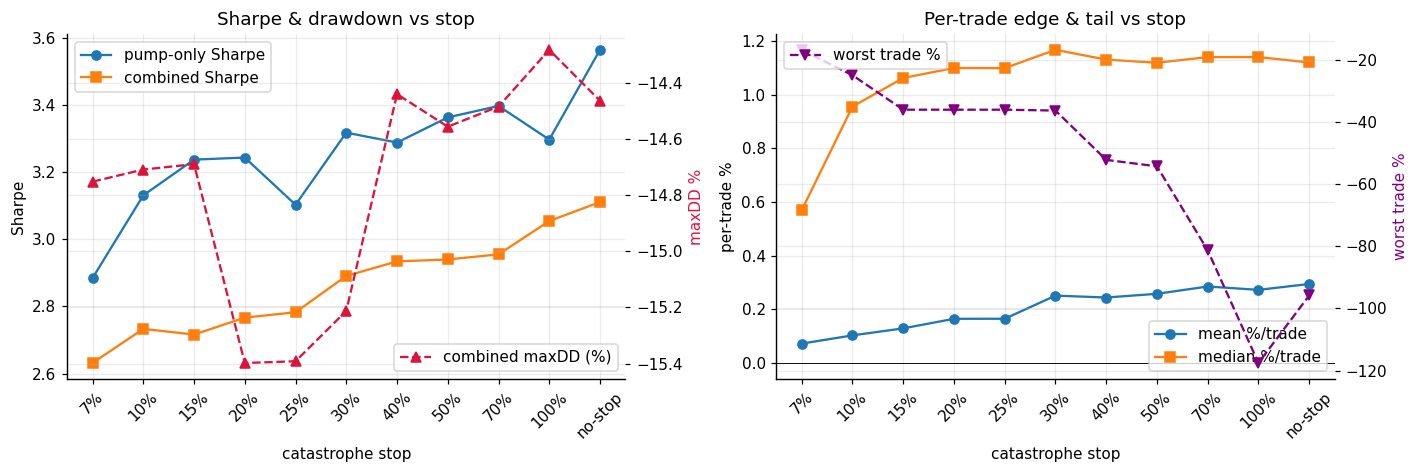

In [3]:
import matplotlib.pyplot as plt
xi=np.arange(len(R)); xt=R["stop"].values
fig,(a1,a2)=plt.subplots(1,2,figsize=(13,4.4))
a1.plot(xi,R.pu_sharpe,"o-",label="pump-only Sharpe"); a1.plot(xi,R.cb_sharpe,"s-",label="combined Sharpe")
a1b=a1.twinx(); a1b.plot(xi,R.cb_dd,"^--",color="crimson",label="combined maxDD (%)")
a1.set_xticks(xi); a1.set_xticklabels(xt,rotation=45); a1.set_xlabel("catastrophe stop")
a1.set_ylabel("Sharpe"); a1b.set_ylabel("maxDD %",color="crimson")
a1.set_title("Sharpe & drawdown vs stop"); a1.legend(loc="upper left"); a1b.legend(loc="lower right")
a2.plot(xi,R["mean"],"o-",label="mean %/trade"); a2.plot(xi,R["median"],"s-",label="median %/trade")
a2b=a2.twinx(); a2b.plot(xi,R["worst"],"v--",color="purple",label="worst trade %")
a2.set_xticks(xi); a2.set_xticklabels(xt,rotation=45); a2.set_xlabel("catastrophe stop")
a2.set_ylabel("per-trade %"); a2b.set_ylabel("worst trade %",color="purple")
a2.axhline(0,color="k",lw=0.6); a2.set_title("Per-trade edge & tail vs stop")
a2.legend(loc="lower right"); a2b.legend(loc="upper left")
show("comb_11_sweep")

## Verdict — the compromise is a ~25–30% catastrophe stop

Three things the sweep tells us:

**1. The median edge plateaus early (~15%) and never improves after.** median
per-trade rises 7%→15% (+0.57% → +1.06%) then is flat at ~+1.1% all the way to
no-stop. So **a stop tighter than ~15% throws away real edge** — it ejects fades
before they revert (the nb10 lesson). Anything ≥15% keeps the full per-trade edge.

**2. The single-trade tail is flat at −36% from 15% to 30%, then blows out.**
worst trade: 7% −17% → 15–30% **−36%** → 40% −52% → 70% −81% → no-stop −96%. There's
a clean **knee at 30%**: below it the worst case is pinned ~−36%; above it you start
eating the big runner gaps. So **30% is the widest stop that still caps the tail
hard.**

**3. In-sample, wider = slightly higher Sharpe — but maxDD ignores the stop entirely.**
Combined Sharpe drifts up 2.63 (7%) → 2.89 (30%) → 3.11 (no-stop), and pump-only
peaks at no-stop (3.56). YET the portfolio **maxDD is flat ~−14.5% (combined) /
~−9% (pump-only) at every stop** — the catastrophe stop does *not* reduce drawdown
in 2024–26. Why: at 2% sizing a −96% trade is only −1.9% of equity, and the runners
didn't cluster. **This is exactly the dump-nb09 result mirrored: tail protection
costs a little return and barely cuts in-sample DD, because the sample had no true
alt-mania.** Its payout is in the unsampled blow-up, not the backtest.

**The compromise (my pick): −25% to −30%.**

| | no-stop | **30% stop** | what you trade |
|---|---|---|---|
| combined Sharpe | 3.11 | **2.89** | give up ~7% of Sharpe |
| combined final ($1k, 2%) | $11.2k | **$9.7k** | give up ~13% of return |
| median per-trade | +1.12% | **+1.17%** | no loss of edge |
| **worst single trade** | **−96%** | **−36%** | cut the catastrophe ~2.7× |
| maxDD (in-sample) | −14.5% | −15.2% | ~flat (DD isn't the point) |

You give up a sliver of in-sample Sharpe/return and in exchange cap any single
short blow-up at ~−36% instead of −96% (and bound the *unbounded* short risk that
2024–26 simply never triggered). That insurance is cheap and the protection is real
precisely where the backtest is blind — a live alt-mania. Below ~15% you're back to
the stop killing the edge; above ~30% the tail grows for almost no extra Sharpe.

**Next:** (1) layer the capacity model (nb08) onto the 30%-stop combined for the
realistic small-account number; (2) add a market-wide melt-up kill-switch (mirror
dump nb09) — the correlated-cluster protection that a per-trade stop can't give;
(3) graduate to a paper bot at 2% size with the −30% stop default-on.

Caveats: in-sample (no true alt-mania in 2024–26, so even −96% may understate a
live worst case); idealized engine (no capacity / no entry slippage at the pump
top); each stop retrains its own classifier so kept-sets differ slightly (part of
the small Sharpe wiggle is that, not signal).